## Simulation of Call Option Prices via SDE

### Inputs
- Final time $T$
- Number of steps $N$
- Initial value $X_0 = x_0$
- Drift function $\mu(x, t)$
- Diffusion function $\sigma(x, t)$

### Euler-Maruyama Discretization
1. Set $\Delta t = T/N$, define grid $t_n = n \Delta t$
2. Initialize $X_0 = x_0$
3. For $n = 0$ to $N - 1$:
    - Sample $\Delta W_n \sim \mathcal{N}(0, \Delta t)$
    - Compute:

      $$
      X_{n+1} = X_n + \mu(X_n, t_n) \Delta t + \sigma(X_n, t_n) \Delta W_n
      $$

## Geometric Brownian Motion (GBM)

GBM SDE:
$$
dX_t = \mu X_t \, dt + \sigma X_t \, dW_t
$$

with closed-form solution:
$$
X_t = X_0 \exp \left( \left( \mu - \frac{\sigma^2}{2} \right)t + \sigma W_t \right)
$$

Euler–Maruyama approximation for GBM:
$$
X_{n+1} = X_n + \mu X_n \Delta t + \sigma X_n \Delta W_n
$$

## Evaluating using Monte Carlo Methods for risk-neutral frameworks
1. Simulate $M$ sample paths $\{ S_T^{(i)} \}_{i=1}^M$ using Euler–Maruyama.

2. Compute option payoffs $f(S_T^{(i)})$ for each path based on the option type.

3. Take the average of payoffs:  
   $$
   \hat{P} = \frac{1}{M} \sum_{i=1}^{M} f(S_T^{(i)}).
   $$

4. Discount to present value:  
   $$
   V_0 = e^{-rT} \cdot \hat{P}.
   $$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact_manual

In [5]:
def euler_maruyama_paths(S0, T, n_steps, drift, diffusion, n_paths):
    # Simulating the euler-maruyama processes
    dt = T / n_steps

    S = np.zeros((n_paths, n_steps + 1))
    S[:, 0] = S0

    for i in range(1, n_steps + 1):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        S[:, i] = S[:, i - 1] + drift * S[:, i - 1] * dt + diffusion * S[:, i - 1] * dW

    return S # (n_paths, n_steps + 1)

def evaluate_option_euler(option_type, S, K, T, rf):
    ST = S[:,-1]
    ST_arith = np.mean(S, axis=1)
    ST_geom = np.exp(np.mean(np.log(S), axis = 1))
    ST_min = np.min(S, axis = 1)

    # Calculating payoff of each option type
    if option_type == "euro_call":
        P = np.maximum(ST - K, 0).mean()

    elif option_type == "arith_asian_call":
        P = np.maximum(ST_arith - K, 0).mean()

    elif option_type == "geom_asian_call":
        P = np.maximum(ST_geom - K, 0).mean()

    elif option_type == "float_lback_call":
        P = np.maximum(ST - ST_min, 0).mean()

    else:
        raise ValueError("option_type must be one of: 'euro_call', 'arith_asian_call', 'geom_asian_call', 'float_lback_call'")

    return np.exp(-rf * T) * P, P

def run_sim(option_type, S0, drift, diffusion, T, n_steps, n_paths, K, rf):
    S = euler_maruyama_paths(S0, T, n_steps, drift, diffusion, n_paths)
    price, payoff = evaluate_option_euler(option_type, S, K, T, rf)
    print(f"Option Price: {price:.2f} \nPayoff: {payoff:.2f}")

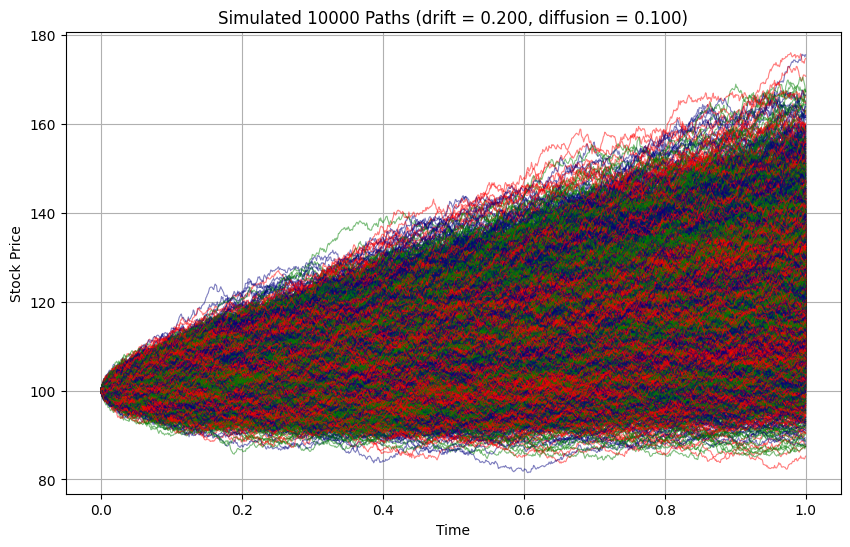


Option Type : euro_call
Payoff(undiscounted) : 12.99
Option Price : 12.35


Option Type : arith_asian_call
Payoff(undiscounted) : 2.98
Option Price : 2.84


Option Type : geom_asian_call
Payoff(undiscounted) : 2.77
Option Price : 2.64


Option Type : float_lback_call
Payoff(undiscounted) : 24.37
Option Price : 23.18



In [ ]:
# Calculating the Prices for the four types using the following values

S0 = 100 #Spot Price
T = 1 #Time to maturity in years
n_steps = 1000 #Steps to discretization
drift = 0.2 #drift for GBM
diffusion = 0.1 #diffusion for GBM
n_paths = 10000 #number of paths for Monte Carlo Estimation
paths = euler_maruyama_paths(S0, T, n_steps, drift, diffusion, n_paths) #simulating the path


# Plotting the paths
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'navy']
for i in range(n_paths):
    plt.plot(np.linspace(0, T, n_steps + 1), paths[i], lw=0.8, alpha=0.5, color=colors[i%3])
plt.title(f'Simulated {n_paths} Paths (drift = {drift:.3f}, diffusion = {diffusion:.3f})')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.grid()
plt.show()

K = 110 #Strike price to evaluate price of option
rf = 0.05 #risk-free rate for discounting

for option in ['euro_call', 'arith_asian_call', 'geom_asian_call', 'float_lback_call']:
    price, payoff = evaluate_option_euler(option, paths, K, T, rf)
    print(f"\nOption Type : {option}\nPayoff(undiscounted) : {payoff:.2f}\nOption Price : {price:.2f}\n")